In [1]:
%pip install matplotlib deap 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Required Libraries
import random
import numpy as np
import math
import matplotlib.pyplot as plt #type: ignore
from deap import base, creator, tools, algorithms #type: ignore

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Pre Requisite Values
num_locations=20

locations=[(random.randint(-100, 100), random.randint(-100, 100)) for _ in range(num_locations)]

depot=(0,0)

num_vehicles=4

# print(num_locations)
# print(locations)

In [4]:
# Genetic Algorithm Setup
creator.create("FitnessMin", base.Fitness, weights=(-1.0,-1.0))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("indices", random.sample, range(num_locations), num_locations)

toolbox.register("individual",tools.initIterate,creator.Individual,toolbox.indices)  #finish defining how to build an individual)
toolbox.register("population",tools.initRepeat,list,toolbox.individual) #finish defining how to build an population)

# print(toolbox.population(100))

In [5]:
# Fitness Function
def evalVRP(individual):
    x,y=depot
    totalDistance=0
    distances=[]
    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]
        # Calculate total distance traveled by this vehicle
        vehicle_distance = sum(np.linalg.norm(np.array(vehicle_route[k+1]) - np.array(vehicle_route[k])) for k in range(len(vehicle_route)-1))
        totalDistance += vehicle_distance
        distances.append(vehicle_distance)
    balance_penalty = np.std(distances)  # Use standard deviation of distances as a penalty for imbalance among vehicles
    return totalDistance, balance_penalty

In [6]:
#Genetic Operators
toolbox.register("evaluate", evalVRP)
toolbox.register("mate",tools.cxPartialyMatched) # Choose and configure a crossover method)
toolbox.register("mutate",tools.mutShuffleIndexes,indpb=0.05) # Choose and configure a mutation method)
toolbox.register("select",tools.selTournament,tournsize=3)

In [7]:
def plot_routes(individual, title="Routes"):
    plt.figure()
    # Plot locations as blue dots and the depot as a red square
    for (x, y) in locations:
        plt.plot(x, y, 'bo')
    plt.plot(depot[0], depot[1], 'rs')

    # Draw routes for each vehicle
    for i in range(num_vehicles):
        vehicle_route = [depot] + [locations[individual[j]] for j in range(i, len(individual), num_vehicles)] + [depot]
        plt.plot(*zip(*vehicle_route), '-')

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.show()

In [8]:
def main():
    random.seed(42)  # Seed for reproducibility
    pop = toolbox.population(300)  # Generate initial population
    hof = tools.HallOfFame(1)  # Hall of Fame to store the best individual

    # Setup statistics to track
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)

    # Run the genetic algorithm
    algorithms.eaSimple(pop, toolbox, 0.7, 0.2, 300, stats=stats, halloffame=hof)

    # Plot the best route found
    plot_routes(hof[0], "Optimal Route")
    return pop, stats, hof


gen	nevals	avg    	min    
0  	300   	1311.11	6.71493
1  	213   	1264.12	6.71493
2  	243   	1247.01	14.9571
3  	232   	1235.86	10.2418
4  	233   	1232.13	12.604 
5  	218   	1225.75	17.9394
6  	213   	1217.51	13.2647
7  	233   	1204.34	16.3498
8  	219   	1191.47	11.9655
9  	209   	1174.11	17.2837
10 	224   	1169.6 	9.02181
11 	230   	1172.39	14.4457
12 	230   	1153.58	30.7261
13 	217   	1112.38	12.583 
14 	231   	1081.77	16.0998
15 	250   	1056.04	13.5897
16 	238   	1020.27	15.6444
17 	236   	986.909	19.2817
18 	225   	968.054	16.4297
19 	225   	952.983	12.2003
20 	209   	940.718	14.9868
21 	232   	938.032	18.9113
22 	237   	938.815	19.3491
23 	217   	938.434	5.74686
24 	227   	925.95 	5.74686
25 	246   	907.378	11.8807
26 	233   	892.154	19.2782
27 	219   	878.456	9.4412 
28 	229   	857.725	20.5869
29 	223   	848.419	9.82818
30 	238   	844.534	20.7733
31 	225   	832.754	12.6818
32 	221   	827.177	10.0608
33 	243   	822.839	12.7087
34 	232   	817.224	21.0403
35 	244   	805.993	15.5869
3

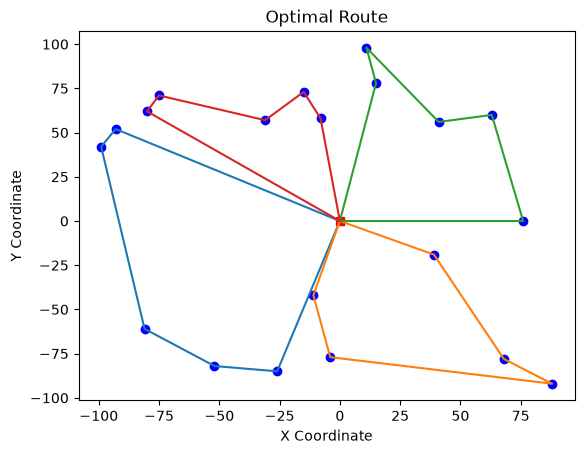

In [9]:
if __name__ == "__main__":
    main()